# CMPE 255 Assignment 1 — Part 2
## Experiment 2: Customer Segmentation with K-Means Clustering

### AI-Assisted Replication of Instructor Data Science Experiment

This notebook replicates and adapts the customer clustering experiment from the instructor's `data_science_examples` repository.

Unlike supervised machine learning, clustering does not require a target label. Instead, the goal is to discover meaningful groups of customers based on similarities in their characteristics and behavior.

### Objectives

- Explore customer characteristics
- Prepare numerical features for clustering
- Standardize variables with different scales
- Use the Elbow Method to investigate the number of clusters
- Apply K-Means clustering
- Evaluate clustering quality using the Silhouette Score
- Visualize customer segments
- Build cluster profiles
- Translate the clusters into business insights

### Adaptation

The instructor's original project explored customer clustering as a broader data science application. For this assignment, the experiment is adapted into a reproducible notebook focused on the core unsupervised machine learning workflow and interpretable customer segments.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Business Understanding

Customer segmentation helps organizations divide customers into groups with similar characteristics or purchasing behavior.

These segments can support:

- Personalized marketing
- Customer retention strategies
- Product recommendations
- Loyalty programs
- Resource allocation

This experiment uses a reproducible synthetic customer dataset containing demographic and behavioral variables.

Because clustering is an unsupervised learning task, there is no target variable to predict. The objective is to discover meaningful customer groups directly from the feature patterns.

In [20]:
# Create a reproducible synthetic customer dataset

np.random.seed(42)

n_customers = 1000

customer_data = pd.DataFrame({
    "customer_id": range(1, n_customers + 1),

    "age": np.random.randint(
        18,
        70,
        n_customers
    ),

    "annual_income": np.random.normal(
        65000,
        22000,
        n_customers
    ),

    "spending_score": np.random.uniform(
        1,
        100,
        n_customers
    ),

    "purchase_frequency": np.random.poisson(
        8,
        n_customers
    ),

    "average_order_value": np.random.normal(
        85,
        30,
        n_customers
    )
})

# Keep values within reasonable ranges

customer_data["annual_income"] = customer_data[
    "annual_income"
].clip(lower=15000)

customer_data["average_order_value"] = customer_data[
    "average_order_value"
].clip(lower=10)

print("Dataset shape:", customer_data.shape)

customer_data.head()

Dataset shape: (1000, 6)


,customer_id,age,annual_income,spending_score,purchase_frequency,average_order_value
0,1,56,29658.180954,99.637099,11,20.160883
1,2,69,69476.199989,37.462644,11,99.476011
2,3,46,48360.283604,45.412452,9,104.810292
3,4,32,33710.418389,72.485023,14,107.426384
4,5,60,50775.396547,88.733382,13,73.148594


## 2. Data Understanding

The synthetic dataset contains 1,000 customers.

The variables are:

- `customer_id` — unique customer identifier
- `age` — customer age
- `annual_income` — estimated annual income
- `spending_score` — behavioral spending score from 1 to 100
- `purchase_frequency` — number of purchases in a representative period
- `average_order_value` — average monetary value of customer orders

The customer ID is only an identifier and will not be used for clustering.

In [21]:
print("Dataset shape:")
print(customer_data.shape)

print("\nMissing values:")
print(customer_data.isnull().sum())

print("\nData types:")
print(customer_data.dtypes)

Dataset shape:
(1000, 6)

Missing values:
customer_id            0
age                    0
annual_income          0
spending_score         0
purchase_frequency     0
average_order_value    0
dtype: int64

Data types:
customer_id              int64
age                      int64
annual_income          float64
spending_score         float64
purchase_frequency       int64
average_order_value    float64
dtype: object


In [22]:
customer_data.describe()

,customer_id,age,annual_income,spending_score,purchase_frequency,average_order_value
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,66336.562090,50.089569,7.944000,84.659117
std,288.819436,14.99103,21559.959415,28.659070,2.646104,28.723851
min,1.000000,18.00000,15000.000000,1.001152,1.000000,10.000000
25%,250.750000,31.00000,51539.618453,26.673211,6.000000,65.154229
50%,500.500000,44.00000,66184.378779,49.827353,8.000000,85.288722
75%,750.250000,56.00000,80080.344585,75.436941,10.000000,103.974868
max,1000.000000,69.00000,122912.405426,99.836404,16.000000,172.423276


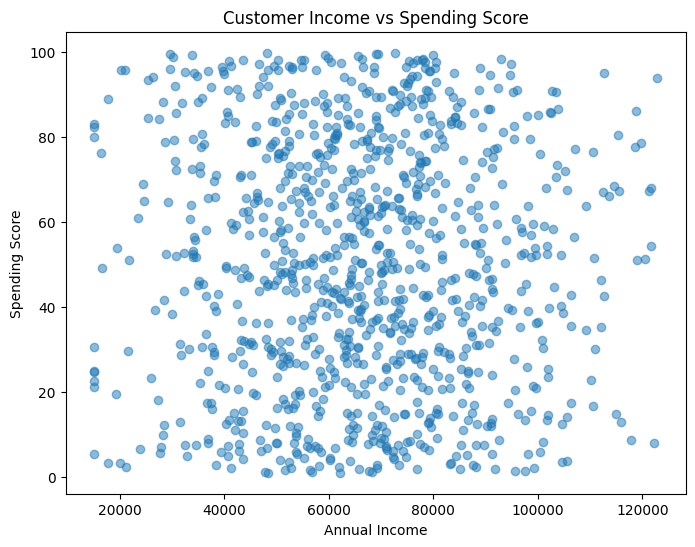

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    customer_data["annual_income"],
    customer_data["spending_score"],
    alpha=0.5
)

plt.title("Customer Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

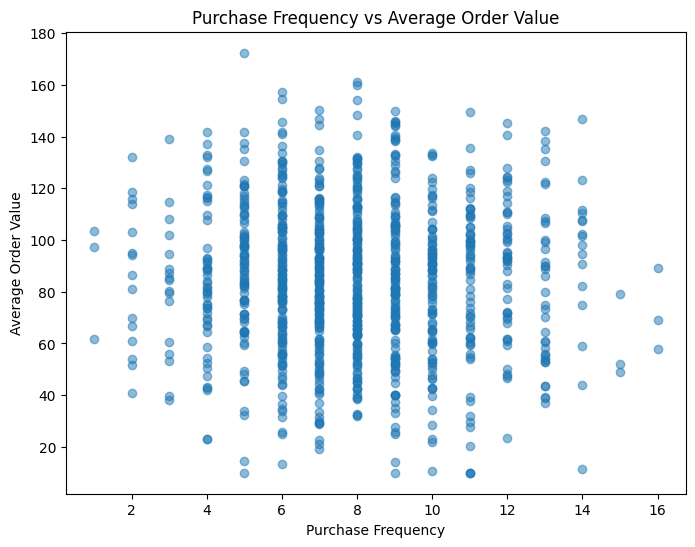

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    customer_data["purchase_frequency"],
    customer_data["average_order_value"],
    alpha=0.5
)

plt.title("Purchase Frequency vs Average Order Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Average Order Value")

plt.show()

### Creating Latent Customer Behavior Patterns

To make the clustering experiment meaningful, the synthetic data is generated from several underlying customer behavior patterns.

These hidden patterns are used only to simulate realistic variation in customer behavior. They are **not provided to the K-Means algorithm as labels**.

The clustering model must discover customer structure using only the numerical customer features.

In [25]:
np.random.seed(42)

segment_size = 250

segments = []

# Segment A:
# lower income, lower spending
segment_a = pd.DataFrame({
    "age": np.random.normal(45, 8, segment_size),
    "annual_income": np.random.normal(35000, 6000, segment_size),
    "spending_score": np.random.normal(30, 8, segment_size),
    "purchase_frequency": np.random.normal(4, 1.5, segment_size),
    "average_order_value": np.random.normal(45, 10, segment_size)
})

# Segment B:
# higher income, high spending
segment_b = pd.DataFrame({
    "age": np.random.normal(38, 7, segment_size),
    "annual_income": np.random.normal(95000, 10000, segment_size),
    "spending_score": np.random.normal(80, 7, segment_size),
    "purchase_frequency": np.random.normal(14, 2, segment_size),
    "average_order_value": np.random.normal(130, 15, segment_size)
})

# Segment C:
# medium income, frequent purchases
segment_c = pd.DataFrame({
    "age": np.random.normal(30, 6, segment_size),
    "annual_income": np.random.normal(60000, 8000, segment_size),
    "spending_score": np.random.normal(65, 8, segment_size),
    "purchase_frequency": np.random.normal(18, 2, segment_size),
    "average_order_value": np.random.normal(65, 10, segment_size)
})

# Segment D:
# higher income, conservative spending
segment_d = pd.DataFrame({
    "age": np.random.normal(55, 7, segment_size),
    "annual_income": np.random.normal(85000, 9000, segment_size),
    "spending_score": np.random.normal(25, 7, segment_size),
    "purchase_frequency": np.random.normal(6, 1.5, segment_size),
    "average_order_value": np.random.normal(90, 12, segment_size)
})

segments = [
    segment_a,
    segment_b,
    segment_c,
    segment_d
]

customer_data = pd.concat(
    segments,
    ignore_index=True
)

customer_data.insert(
    0,
    "customer_id",
    range(1, len(customer_data) + 1)
)

# Keep variables within reasonable ranges

customer_data["age"] = customer_data["age"].clip(
    18,
    75
)

customer_data["spending_score"] = customer_data[
    "spending_score"
].clip(
    1,
    100
)

customer_data["purchase_frequency"] = customer_data[
    "purchase_frequency"
].clip(lower=1)

print("Final customer dataset shape:", customer_data.shape)

customer_data.head()

Final customer dataset shape: (1000, 6)


,customer_id,age,annual_income,spending_score,purchase_frequency,average_order_value
0,1,48.973713,27434.696274,37.409420,2.615150,58.993554
1,2,43.893886,40507.171682,45.275333,1.972473,54.246337
2,3,50.181508,47732.937182,18.811459,2.536190,45.596304
3,4,57.184239,41194.791563,34.503754,5.580463,38.530632
4,5,43.126773,25883.780204,24.794859,2.575902,51.982233


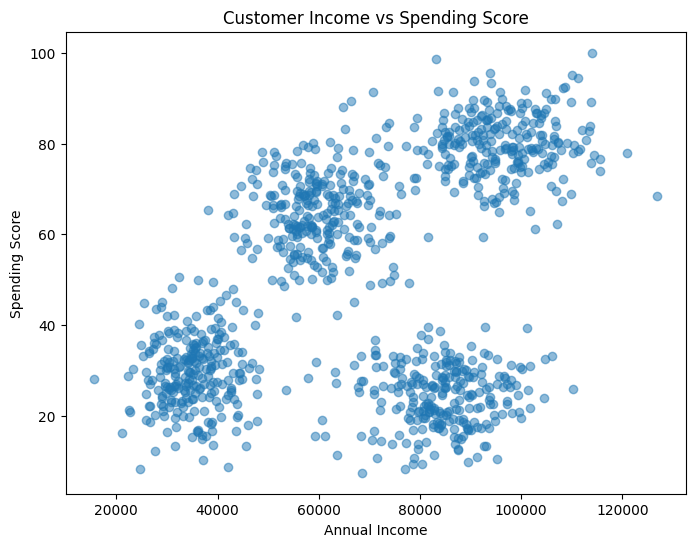

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    customer_data["annual_income"],
    customer_data["spending_score"],
    alpha=0.5
)

plt.title("Customer Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

## 3. Data Preparation

K-Means clustering is based on distances between observations.

The variables in this dataset use very different numerical scales. For example, annual income is measured in tens of thousands of dollars, while spending score ranges approximately from 1 to 100.

Without scaling, variables with large numerical values could dominate the distance calculation.

Therefore, the customer features are standardized before clustering using `StandardScaler`.

In [27]:
clustering_features = [
    "age",
    "annual_income",
    "spending_score",
    "purchase_frequency",
    "average_order_value"
]

X = customer_data[clustering_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original feature shape:", X.shape)
print("Scaled feature shape:", X_scaled.shape)

Original feature shape: (1000, 5)
Scaled feature shape: (1000, 5)


## 4. Selecting the Number of Clusters

K-Means requires the number of clusters (`k`) to be specified before training.

The Elbow Method compares the within-cluster sum of squares, also called inertia, across different values of `k`.

A useful value of `k` is often located near the point where additional clusters produce diminishing improvements.

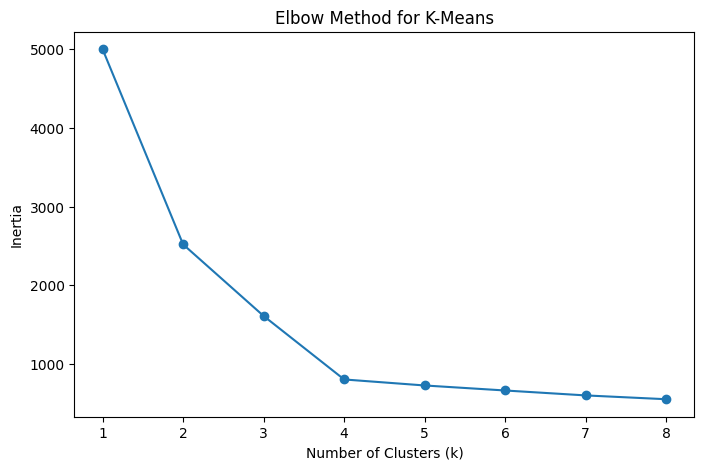

In [28]:
inertia_values = []

k_values = range(1, 9)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia_values.append(
        model.inertia_
    )

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))

plt.show()

In [29]:
silhouette_results = {}

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_results[k] = score

    print(
        "k =",
        k,
        "| Silhouette Score =",
        round(score, 4)
    )

k = 2 | Silhouette Score = 0.4632
k = 3 | Silhouette Score = 0.5011
k = 4 | Silhouette Score = 0.5766
k = 5 | Silhouette Score = 0.5025
k = 6 | Silhouette Score = 0.4177
k = 7 | Silhouette Score = 0.3474
k = 8 | Silhouette Score = 0.2612


### Cluster Selection

Both evaluation approaches support selecting **four clusters**.

The Elbow Method shows a substantial reduction in inertia between one and four clusters, followed by much smaller improvements after `k = 4`.

The Silhouette Score provides additional evidence. Among the tested values, `k = 4` achieved the highest score of **0.5766**, compared with 0.5011 for three clusters and 0.5025 for five clusters.

Therefore, four clusters are selected for the final K-Means model.

In [30]:
# Train the final K-Means model

final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data["cluster"] = final_kmeans.fit_predict(
    X_scaled
)

print("Customers in each cluster:")
print(
    customer_data["cluster"]
    .value_counts()
    .sort_index()
)

Customers in each cluster:
cluster
0    250
1    249
2    251
3    250
Name: count, dtype: int64


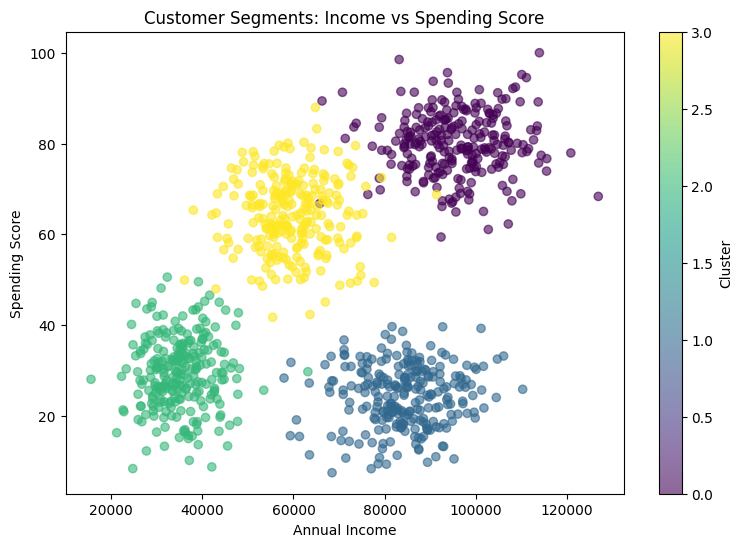

In [31]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    customer_data["annual_income"],
    customer_data["spending_score"],
    c=customer_data["cluster"],
    alpha=0.6
)

plt.title("Customer Segments: Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

### PCA Visualization

The K-Means model uses five customer features, which cannot be directly visualized in a two-dimensional chart.

Principal Component Analysis (PCA) is therefore used to project the standardized five-dimensional customer data into two dimensions for visualization.

PCA is used here only for visualization. The K-Means model itself was trained using all five standardized features.

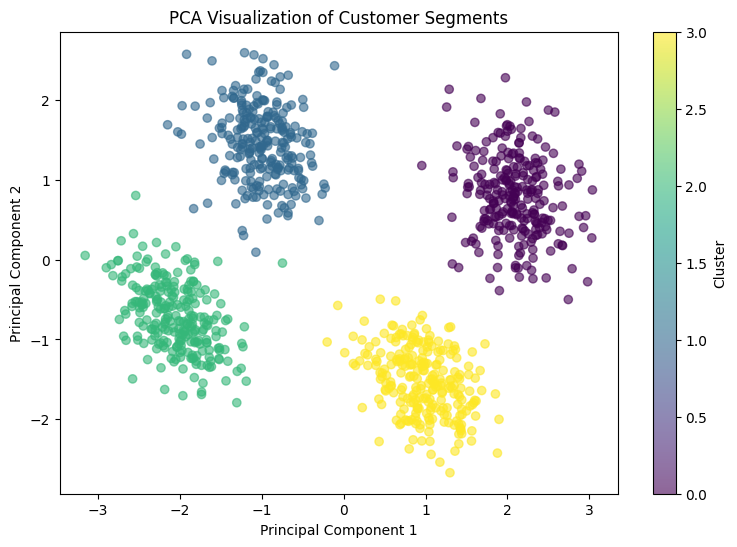

In [32]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=customer_data["cluster"],
    alpha=0.6
)

plt.title("PCA Visualization of Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

In [33]:
cluster_profiles = (
    customer_data
    .groupby("cluster")[clustering_features]
    .mean()
    .round(2)
)

cluster_profiles

,age,annual_income,spending_score,purchase_frequency,average_order_value
cluster,,,,,
0,38.74,95665.29,79.99,13.91,130.30
1,54.43,84226.80,24.33,6.02,89.70
2,44.95,35208.41,29.46,4.21,46.25
3,30.58,59660.70,64.32,18.09,65.52


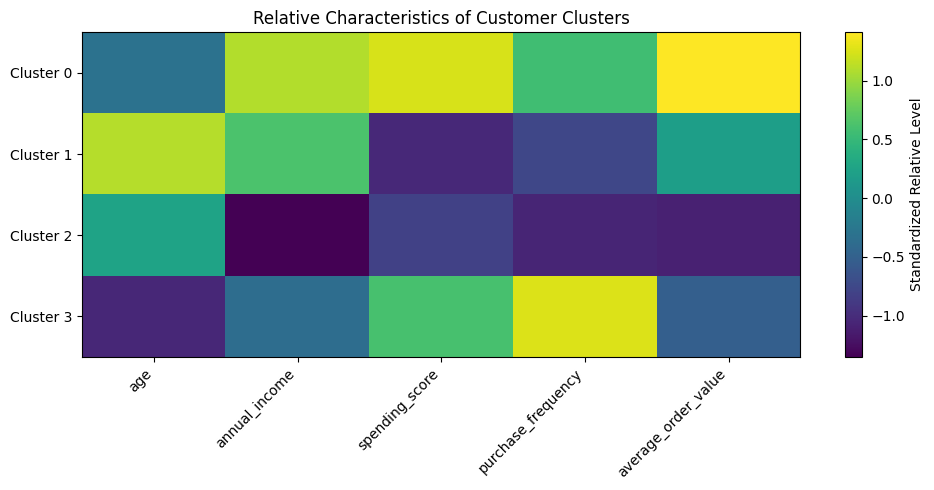

In [34]:
profile_scaled = pd.DataFrame(
    scaler.transform(
        cluster_profiles[clustering_features]
    ),
    columns=clustering_features,
    index=cluster_profiles.index
)

plt.figure(figsize=(10, 5))

plt.imshow(
    profile_scaled,
    aspect="auto"
)

plt.colorbar(
    label="Standardized Relative Level"
)

plt.xticks(
    range(len(clustering_features)),
    clustering_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(profile_scaled.index)),
    [
        "Cluster " + str(i)
        for i in profile_scaled.index
    ]
)

plt.title("Relative Characteristics of Customer Clusters")

plt.tight_layout()

plt.show()

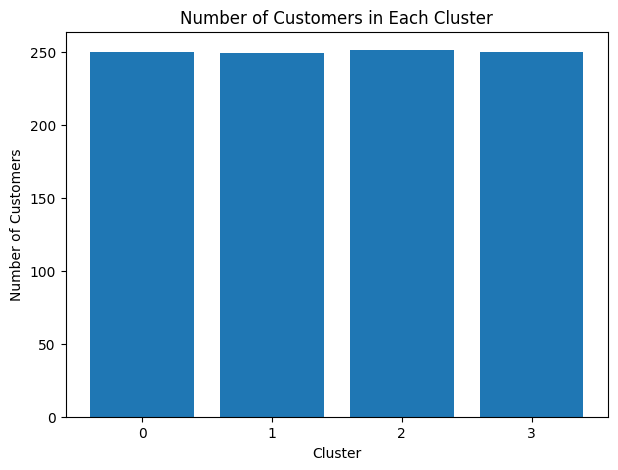

In [35]:
cluster_counts = (
    customer_data["cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [36]:
# Assign interpretable business names to the discovered clusters

cluster_names = {
    0: "Premium High-Value Customers",
    1: "Conservative Affluent Customers",
    2: "Budget / Low-Engagement Customers",
    3: "Frequent Value Shoppers"
}

customer_data["segment_name"] = customer_data[
    "cluster"
].map(cluster_names)

customer_data[
    [
        "customer_id",
        "cluster",
        "segment_name"
    ]
].head(10)

,customer_id,cluster,segment_name
0,1,2,Budget / Low-Engagement Customers
1,2,2,Budget / Low-Engagement Customers
2,3,2,Budget / Low-Engagement Customers
3,4,2,Budget / Low-Engagement Customers
4,5,2,Budget / Low-Engagement Customers
5,6,2,Budget / Low-Engagement Customers
6,7,2,Budget / Low-Engagement Customers
7,8,2,Budget / Low-Engagement Customers
8,9,2,Budget / Low-Engagement Customers
9,10,2,Budget / Low-Engagement Customers


## 5. Cluster Interpretation

The four discovered clusters represent distinct customer profiles.

### Cluster 0 — Premium High-Value Customers

Customers in this cluster have the highest average annual income (approximately $95,665), the highest spending score (79.99), and the highest average order value (approximately $130).

They also purchase relatively frequently.

This segment represents highly valuable customers who combine strong purchasing power with high spending behavior.

### Cluster 1 — Conservative Affluent Customers

These customers are older on average (approximately 54 years old) and have relatively high annual income (approximately $84,227), but their spending score is only 24.33.

Their purchase frequency is also relatively low.

This group has substantial purchasing power but appears more conservative in its spending behavior.

### Cluster 2 — Budget / Low-Engagement Customers

This cluster has the lowest average annual income (approximately $35,208), low spending scores, the lowest purchase frequency, and the lowest average order value.

These customers appear to be relatively price-sensitive or less engaged with the business.

### Cluster 3 — Frequent Value Shoppers

Customers in this segment are the youngest group on average (approximately 31 years old).

Their income is moderate, but they have a relatively high spending score and the highest purchase frequency at approximately 18 purchases per period.

Their average order value is lower than that of premium customers, suggesting frequent but more moderately priced purchases.

## 6. Business Recommendations

The customer segments can support differentiated marketing strategies.

### Premium High-Value Customers

The business could focus on:

- VIP loyalty programs
- Premium product recommendations
- Early access to new products
- Personalized retention offers

Because these customers already demonstrate high spending behavior, retention may be especially valuable.

### Conservative Affluent Customers

Potential strategies include:

- Personalized recommendations
- Premium product education
- Targeted promotions
- Incentives designed to increase purchase frequency

This segment may represent an opportunity to convert purchasing power into stronger engagement.

### Budget / Low-Engagement Customers

Possible strategies include:

- Discounts
- Entry-level products
- Promotional bundles
- Re-engagement campaigns

Marketing costs should also be monitored because this group currently generates relatively low engagement.

### Frequent Value Shoppers

Potential strategies include:

- Loyalty rewards
- Subscription programs
- Cross-selling
- Purchase-frequency incentives

Because these customers already purchase frequently, increasing average order value could be an important business opportunity.

## 7. Limitations

This experiment uses synthetic customer data generated specifically to demonstrate the clustering workflow.

The data contains simulated underlying behavioral patterns, so the resulting clusters should not be interpreted as evidence about real customers.

In a real business application, the same workflow could be applied to actual customer transaction, demographic, and engagement data.

Additional validation would also be required to determine whether the discovered segments are stable, actionable, and useful for business decisions.

The purpose of this experiment is to reproduce and demonstrate the methodology of customer segmentation using unsupervised machine learning.

## 8. Experiment Conclusion

This experiment replicated and adapted the instructor's customer clustering project using an unsupervised machine learning workflow.

The analysis included:

- Customer data exploration
- Feature standardization
- Elbow Method analysis
- Silhouette Score evaluation
- K-Means clustering
- PCA visualization
- Cluster profiling
- Business interpretation
- Segment-specific recommendations

Both the Elbow Method and Silhouette analysis supported selecting **four clusters**.

The final four customer segments were interpreted as:

1. **Premium High-Value Customers**
2. **Conservative Affluent Customers**
3. **Budget / Low-Engagement Customers**
4. **Frequent Value Shoppers**

The four-cluster solution achieved a Silhouette Score of **0.5766**, indicating reasonably well-separated customer groups in the synthetic dataset.

This experiment demonstrates how unsupervised machine learning can transform multidimensional customer data into interpretable segments that could support targeted business strategies.